# Biogas NPV simulation

Run the biogas electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity_model import simulate_biogas_npv

In [2]:
SAMPLE_SIZE = 1000000
#RANDOM_SEED = 42

rng = np.random.default_rng() 
simulation = simulate_biogas_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()

,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,biogas,1000000.0,5300.0,188.679245,188679.245283,5274.966946,297.368849,4.125495,2.551980,...,94070000.0,5.610733e+07,4.125495e+06,2.232983e+08,0.0,-1.894611e+08,-3.017731e+09,25000000.0,-120.709255,-0.000121
1,1,biogas,1000000.0,5300.0,188.679245,188679.245283,5450.107541,102.067366,4.083633,2.469636,...,94070000.0,1.925799e+07,4.083633e+06,2.160932e+08,0.0,-1.453648e+08,-2.580059e+09,25000000.0,-103.202362,-0.000103
2,2,biogas,1000000.0,5300.0,188.679245,188679.245283,3711.654148,280.617455,4.210535,2.475980,...,94070000.0,5.294669e+07,4.210535e+06,2.166482e+08,0.0,-1.797355e+08,-2.618948e+09,25000000.0,-104.757921,-0.000105
3,3,biogas,1000000.0,5300.0,188.679245,188679.245283,5630.408549,270.460332,3.639011,2.625100,...,94070000.0,5.103025e+07,3.639011e+06,2.296963e+08,0.0,-1.902955e+08,-3.093703e+09,25000000.0,-123.748139,-0.000124
4,4,biogas,1000000.0,5300.0,188.679245,188679.245283,4674.615381,297.228616,3.805055,2.527288,...,94070000.0,5.608087e+07,3.805055e+06,2.211377e+08,0.0,-1.869537e+08,-2.877691e+09,25000000.0,-115.107652,-0.000115


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
npv_million_eur_per_mwh = results["npv_million_eur_per_mwh"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
        npv_million_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh,NPV million EUR/MWh
count,1000000.000000,1000000.000000,1000000.000000
mean,-2615.537275,-104.621491,-0.000105
std,207.981319,8.319253,0.000008
min,-3243.602706,-129.744108,-0.000130
5%,-2959.682941,-118.387318,-0.000118
50%,-2615.785713,-104.631429,-0.000105
95%,-2271.071979,-90.842879,-0.000091
max,-2016.462982,-80.658519,-0.000081


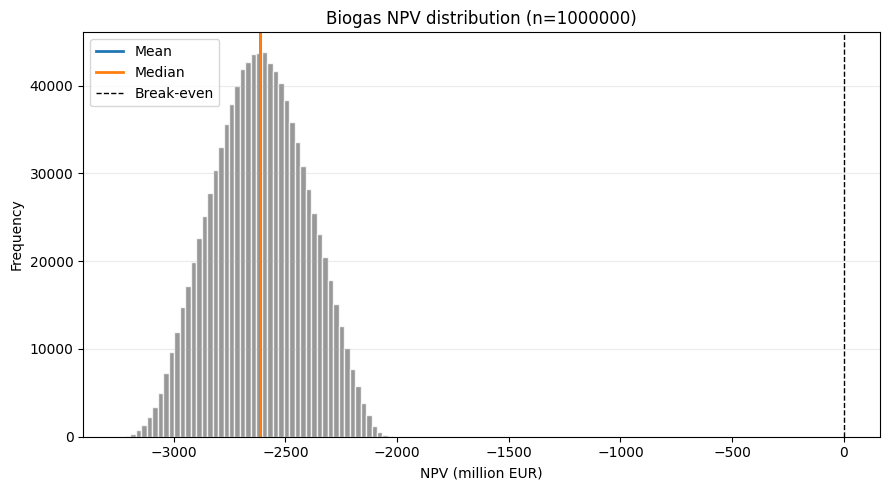

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Biogas NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


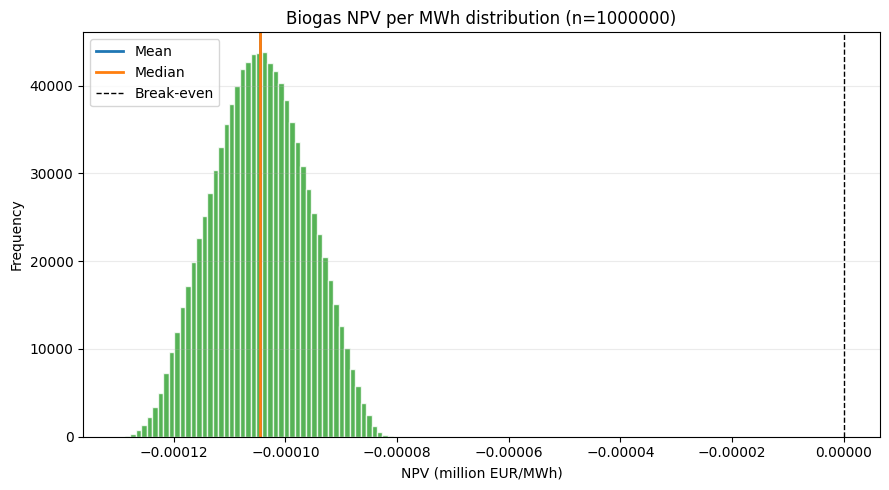

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_million_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_million_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_million_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Biogas NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur            94.070000
annual_fixed_opex_eur         37.137329
annual_variable_opex_eur       4.133185
annual_fuel_cost_eur         221.083403
annual_emissions_cost_eur      0.000000
annual_net_cash_flow_eur    -168.283916
Name: Mean annual value, million EUR, dtype: float64